# H1.Z16 계량기 기초 EDA

## 01. 목적

`H1.Z16` 전기 계량기의 분석 입력 상태와 기초 profile을 확인한다. Isolation Forest 적용 전 단계로, TimescaleDB의 `ems.cr_measurement_1h`에서 데이터를 조회하고 measurement 의미, 적재 상태, 결측, 시간축, 누적 전력량 차분, 주요 전기 변수 profile을 점검한다.

## 02. 데이터 출처

- 시계열 값: TimescaleDB hypertable `ems.cr_measurement_1h`
- 적재/전처리 상태: `ems.full_source_file`
- 대상 계량기: `H1.Z16`
- 계통 해석: `central_cooling` pilot 기준


## 03. Measurement 사전

`H1.Z16` 전기 계량기에서 사용하는 주요 measurement의 의미는 다음과 같다. 한글명은 분석 해석용 명칭이며, 단위와 영문 설명은 DB의 `ems.full_measurement_definition` 기준이다.

| measurement | 한글명 | 단위 | 해석 |
|---|---|---:|---|
| `P` | 유효전력 | W | 전체 3상 기준 실제 일을 하는 전력. 부하 패턴과 이상탐지의 핵심 변수. |
| `P1`, `P2`, `P3` | 상별 유효전력 | W | 1상, 2상, 3상별 유효전력. 상별 부하 불균형 확인에 사용. |
| `W` | 유효전력량 | kWh | 누적 또는 구간 유효 에너지. 모델 입력에서는 차분값 `delta_W`를 우선 사용. |
| `W_in` | 유입 유효전력량 | kWh | 계통에서 유입된 유효 에너지. 소비 방향 에너지 해석에 사용. |
| `W_out` | 유출 유효전력량 | kWh | 계통으로 유출된 유효 에너지. 발전/역방향 흐름 확인에 사용. |
| `I1`, `I2`, `I3` | 상별 전류 | A | 1상, 2상, 3상 전류. `I_imbalance` 파생 feature 생성에 사용. |
| `U1`, `U2`, `U3` | 상별 전압 | V | 1상, 2상, 3상 전압. 전압 안정성과 `U_imbalance` 확인에 사용. |
| `PF` | 역률 | - | 전체 역률. 유효전력 대비 전력 사용 효율과 무효전력 영향을 설명. |
| `PF1`, `PF2`, `PF3` | 상별 역률 | - | 1상, 2상, 3상별 역률. 상별 품질 차이 확인에 사용. |
| `Q` | 무효전력 | var | 실제 일을 하지 않지만 전자기장 형성에 필요한 전력 성분. `Q_ratio` 생성에 사용. |
| `WQ` | 무효전력량 | kvarh | 누적 또는 구간 무효 에너지. 모델 입력에서는 차분값 `delta_WQ`를 우선 사용. |
| `WQ_in` | 유입 무효전력량 | kvarh | 유입 방향 무효 에너지. |
| `WQ_out` | 유출 무효전력량 | kvarh | 유출 방향 무효 에너지. |
| `f` | 계통 주파수 | Hz | 전력망 주파수. 개별 설비 분류보다는 전력 품질/상태 feature로 사용. |


## 04. 분석 계획

1. DB 접속 및 대상 table을 확인한다.
2. `H1.Z16`의 measurement coverage를 확인한다.
3. measurement별 한글 의미와 분석 해석 기준을 정리한다.
4. `1h` 데이터를 조회해 long format에서 wide format으로 변환한다.
5. DB 적재 전처리 상태와 모델 입력 전처리 필요 항목을 확인한다.
6. 결측, 시간축, 누적 전력량 차분, 주요 변수 profile, 상관 구조를 확인한다.


In [1]:
# 01. 기본 설정 및 dependency 확인
from pathlib import Path
import os
import sys
import warnings

warnings.filterwarnings('default')

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'HERMES.md').exists() and (PROJECT_ROOT.parent / 'HERMES.md').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

NOTEBOOK_DIR = PROJECT_ROOT / 'notebooks'
OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'tables' / 'h1_z16_eda'

METER_URN = 'H1.Z16'
EQUIPMENT_GROUP = 'central_cooling'
METER_ROLE = 'consumption'
RESOLUTION = '1h'
SOURCE_TABLE = 'ems.cr_measurement_1h'

QUICK_RUN = os.getenv('EMS_NOTEBOOK_QUICK', '0') == '1'
START_TS = '2023-01-01' if QUICK_RUN else None
END_TS = '2023-03-01' if QUICK_RUN else None
SAVE_OUTPUTS = os.getenv('EMS_SAVE_NOTEBOOK_OUTPUTS', '0') == '1'

In [2]:
# 02. Python package imports
required = {
    'pandas': 'pandas',
    'numpy': 'numpy',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn',
    'psycopg': 'psycopg[binary]',
    'sklearn': 'scikit-learn',
    'koreanize_matplotlib': 'koreanize-matplotlib',
}

missing = []
for module_name, package_name in required.items():
    try:
        __import__(module_name)
    except ImportError:
        missing.append(package_name)

if missing:
    raise ImportError(
        '필수 패키지가 없습니다: ' + ', '.join(missing) +
        '\n예: python -m pip install ' + ' '.join(missing)
    )

import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import psycopg

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

warnings.filterwarnings(
    'ignore',
    message='.*distutils Version classes are deprecated.*',
    category=DeprecationWarning,
)

import koreanize_matplotlib

sns.set_theme(style='whitegrid')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['axes.unicode_minus'] = False

print('pandas:', pd.__version__)

pandas: 3.0.3


c:\Arch Linux\EMS\.venv\Lib\site-packages\koreanize_matplotlib\koreanize_matplotlib.py:16: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  is_support_createFontList = LooseVersion(matplotlib.__version__) < '3.2'
c:\Arch Linux\EMS\.venv\Lib\site-packages\setuptools\_distutils\version.py:336: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  other = LooseVersion(other)


In [3]:
# 03. DB 접속 정보 로드
def load_env_file(env_path: Path) -> None:
    if not env_path.exists():
        return
    for raw in env_path.read_text(encoding='utf-8').splitlines():
        line = raw.strip()
        if not line or line.startswith('#') or '=' not in line:
            continue
        key, value = line.split('=', 1)
        key = key.strip()
        value = value.strip().strip('"').strip("'")
        os.environ.setdefault(key, value)

load_env_file(PROJECT_ROOT / '.env')

required_env = ['DB_HOST', 'DB_PORT', 'DB_NAME', 'DB_USER', 'DB_PASSWORD']
missing_env = [key for key in required_env if not os.getenv(key)]
if missing_env:
    raise RuntimeError(f'DB 접속 환경변수가 없습니다: {missing_env}')

In [4]:
# 04. DB helper
CONNECT_KWARGS = {
    'host': os.environ['DB_HOST'],
    'port': int(os.environ.get('DB_PORT', '5432')),
    'dbname': os.environ['DB_NAME'],
    'user': os.environ['DB_USER'],
    'password': os.environ['DB_PASSWORD'],
}

def query_df(sql: str, params=None) -> pd.DataFrame:
    with psycopg.connect(**CONNECT_KWARGS) as conn:
        with conn.cursor() as cur:
            cur.execute(sql, params)
            cols = [desc.name for desc in cur.description]
            rows = cur.fetchall()
    return pd.DataFrame(rows, columns=cols)

relation_check = query_df("""
SELECT to_regclass(%s) AS relation_name
""", (SOURCE_TABLE,))
relation_check

,relation_name
0,ems.cr_measurement_1h


In [5]:
# 05. 대상 계량기 measurement coverage 확인
coverage_sql = f"""
WITH measurement_map AS (
    SELECT *
    FROM (VALUES
        ('P', '유효전력'),
        ('P1', '1상 유효전력'),
        ('P2', '2상 유효전력'),
        ('P3', '3상 유효전력'),
        ('W', '유효전력량'),
        ('W_in', '유입 유효전력량'),
        ('W_out', '유출 유효전력량'),
        ('I1', '1상 전류'),
        ('I2', '2상 전류'),
        ('I3', '3상 전류'),
        ('U1', '1상 전압'),
        ('U2', '2상 전압'),
        ('U3', '3상 전압'),
        ('PF', '역률'),
        ('PF1', '1상 역률'),
        ('PF2', '2상 역률'),
        ('PF3', '3상 역률'),
        ('Q', '무효전력'),
        ('WQ', '무효전력량'),
        ('WQ_in', '유입 무효전력량'),
        ('WQ_out', '유출 무효전력량'),
        ('f', '계통 주파수')
    ) AS t(measurement, measurement_ko)
)
SELECT
    m.meter_urn,
    m.measurement,
    mm.measurement_ko,
    COALESCE(d.unit, '') AS unit,
    d.description AS description_en,
    count(*) AS rows,
    min(m.ts) AS min_ts,
    max(m.ts) AS max_ts,
    count(*) FILTER (WHERE m.value IS NULL) AS null_rows,
    count(*) FILTER (WHERE m.value::text IN ('NaN', 'Infinity', '-Infinity')) AS non_finite_rows
FROM {SOURCE_TABLE} AS m
LEFT JOIN ems.full_measurement_definition AS d
    ON d.measurement = m.measurement
LEFT JOIN measurement_map AS mm
    ON mm.measurement = m.measurement
WHERE m.meter_urn = %s
GROUP BY
    m.meter_urn,
    m.measurement,
    mm.measurement_ko,
    d.unit,
    d.description
ORDER BY m.measurement
"""
coverage = query_df(coverage_sql, (METER_URN,))
coverage

,meter_urn,measurement,measurement_ko,unit,description_en,rows,min_ts,max_ts,null_rows,non_finite_rows
0,H1.Z16,I1,1상 전류,A,Phase 1 current,52584,2017-12-31 23:00:00+00:00,2023-12-31 22:00:00+00:00,0,0
1,H1.Z16,I2,2상 전류,A,Phase 2 current,52584,2017-12-31 23:00:00+00:00,2023-12-31 22:00:00+00:00,0,0
2,H1.Z16,I3,3상 전류,A,Phase 3 current,52523,2018-01-03 12:00:00+00:00,2023-12-31 22:00:00+00:00,0,0
3,H1.Z16,P,유효전력,W,Active power,52584,2017-12-31 23:00:00+00:00,2023-12-31 22:00:00+00:00,0,0
4,H1.Z16,P1,1상 유효전력,W,Phase 1 active power,52584,2017-12-31 23:00:00+00:00,2023-12-31 22:00:00+00:00,0,0
5,H1.Z16,P2,2상 유효전력,W,Phase 2 active power,52584,2017-12-31 23:00:00+00:00,2023-12-31 22:00:00+00:00,0,0
6,H1.Z16,P3,3상 유효전력,W,Phase 3 active power,52523,2018-01-03 12:00:00+00:00,2023-12-31 22:00:00+00:00,0,0
7,H1.Z16,PF,역률,,Power factor,52583,2018-01-01 00:00:00+00:00,2023-12-31 22:00:00+00:00,0,0
8,H1.Z16,PF1,1상 역률,,Phase 1 power factor,52584,2017-12-31 23:00:00+00:00,2023-12-31 22:00:00+00:00,0,0
9,H1.Z16,PF2,2상 역률,,Phase 2 power factor,52584,2017-12-31 23:00:00+00:00,2023-12-31 22:00:00+00:00,0,0


In [6]:
# 06. 분석 대상 measurement 선정
candidate_measurements = [
    'P', 'P1', 'P2', 'P3',
    'W', 'W_in', 'W_out',
    'I1', 'I2', 'I3',
    'U1', 'U2', 'U3',
    'PF', 'PF1', 'PF2', 'PF3',
    'Q', 'WQ', 'WQ_in', 'WQ_out',
    'f',
]

available_measurements = coverage['measurement'].tolist()
measurements = [m for m in candidate_measurements if m in available_measurements]
missing_measurements = [m for m in candidate_measurements if m not in available_measurements]

print('available selected measurements:', measurements)
print('missing selected measurements:', missing_measurements)
print('measurement count:', len(measurements))

available selected measurements: ['P', 'P1', 'P2', 'P3', 'W', 'W_in', 'W_out', 'I1', 'I2', 'I3', 'U1', 'U2', 'U3', 'PF', 'PF1', 'PF2', 'PF3', 'Q', 'WQ', 'WQ_in', 'WQ_out', 'f']
missing selected measurements: []
measurement count: 22


In [7]:
# 07. H1.Z16 1h 데이터 조회
where_clauses = ["meter_urn = %s", "measurement = ANY(%s)"]
params = [METER_URN, measurements]
if START_TS is not None:
    where_clauses.append('ts >= %s')
    params.append(START_TS)
if END_TS is not None:
    where_clauses.append('ts < %s')
    params.append(END_TS)

raw_sql = f"""
SELECT ts, measurement, value
FROM {SOURCE_TABLE}
WHERE {' AND '.join(where_clauses)}
ORDER BY ts, measurement
"""
raw = query_df(raw_sql, tuple(params))
raw['ts'] = pd.to_datetime(raw['ts'], utc=True)
raw['value'] = pd.to_numeric(raw['value'], errors='coerce')

print('raw shape:', raw.shape)
print('time range:', raw['ts'].min(), '→', raw['ts'].max())
raw.head()

raw shape: (1155286, 3)
time range: 2017-12-31 23:00:00+00:00 → 2024-01-01 00:00:00+00:00


,ts,measurement,value
0,2017-12-31 23:00:00+00:00,I1,1.107802
1,2017-12-31 23:00:00+00:00,I2,1.110238
2,2017-12-31 23:00:00+00:00,P,435.787833
3,2017-12-31 23:00:00+00:00,P1,230.971167
4,2017-12-31 23:00:00+00:00,P2,204.843500


In [8]:
# 08. Long format → Wide format
wide = (
    raw.pivot_table(index='ts', columns='measurement', values='value', aggfunc='mean')
    .sort_index()
)

if len(wide) > 0:
    full_index = pd.date_range(wide.index.min(), wide.index.max(), freq='1h', tz='UTC')
    wide = wide.reindex(full_index)
    wide.index.name = 'ts'

print('wide shape:', wide.shape)
print('columns:', wide.columns.tolist())
wide.head()

wide shape: (52586, 22)
columns: ['I1', 'I2', 'I3', 'P', 'P1', 'P2', 'P3', 'PF', 'PF1', 'PF2', 'PF3', 'Q', 'U1', 'U2', 'U3', 'W', 'WQ', 'WQ_in', 'WQ_out', 'W_in', 'W_out', 'f']


measurement,I1,I2,I3,P,P1,P2,P3,PF,PF1,PF2,...,U1,U2,U3,W,WQ,WQ_in,WQ_out,W_in,W_out,f
ts,,,,,,,,,,,,,,,,,,,,,
2017-12-31 23:00:00+00:00,1.107802,1.110238,NaN,435.787833,230.971167,204.843500,NaN,NaN,0.913802,0.807576,...,228.380833,228.296667,228.641667,NaN,NaN,NaN,NaN,NaN,NaN,50.035167
2018-01-01 00:00:00+00:00,1.101292,1.108417,NaN,432.206000,228.914833,203.272500,NaN,0.994333,0.913500,0.807892,...,227.332500,227.390000,227.714167,1286.01,135.81,135.81,NaN,1286.01,NaN,50.042500
2018-01-01 01:00:00+00:00,1.107000,1.110000,NaN,435.176167,230.607000,204.539833,NaN,0.994000,0.913904,0.807642,...,228.189167,228.084167,228.571667,1286.44,135.85,135.85,NaN,1286.44,NaN,50.044667
2018-01-01 02:00:00+00:00,1.106333,1.109083,NaN,434.345000,230.063250,204.217167,NaN,0.994000,0.913687,0.807642,...,227.923333,227.957500,228.361667,1286.88,135.90,135.90,NaN,1286.88,NaN,50.031000
2018-01-01 03:00:00+00:00,1.106000,1.109333,NaN,434.194167,230.008917,204.162083,NaN,0.994000,0.913617,0.807950,...,227.808333,227.814167,228.180000,1287.31,135.95,135.95,NaN,1287.31,NaN,50.030333



## 05. 전처리 상태 확인

Isolation Forest를 적용하기 전에 현재 DB 데이터가 어느 정도 전처리되어 있는지 확인한다.
확인 항목은 다음과 같다.

1. `full_source_file` 기준 처리 단계, 해상도, 품질 counter
2. `cr_measurement_1h` 기준 row 수, measurement 수, 시간 범위, null/non-finite 여부
3. wide table 기준 시간 간격, 중복 timestamp, 결측률
4. 누적 전력량 계열의 차분 음수 여부
5. Isolation Forest 입력 전 추가 전처리 필요 항목

In [9]:
# 09. full_source_file 기준 H1.Z16 전처리/적재 상태 확인
preprocess_state_sql = """
SELECT
    processing_level,
    resolution_code,
    count(*) AS source_files,
    count(DISTINCT measurement) AS measurements,
    sum(csv_rows) AS csv_rows,
    sum(inserted_rows) AS inserted_rows,
    sum(conflict_rows) AS conflict_rows,
    sum(null_value_rows) AS null_value_rows,
    sum(invalid_value_rows) AS invalid_value_rows,
    sum(invalid_ts_rows) AS invalid_ts_rows,
    sum(non_finite_rows) AS non_finite_rows,
    min(started_at) AS first_load_started,
    max(finished_at) AS last_load_finished
FROM ems.full_source_file
WHERE meter_urn = %s
GROUP BY processing_level, resolution_code
ORDER BY processing_level, resolution_code
"""
preprocess_state = query_df(preprocess_state_sql, (METER_URN,))
preprocess_state

,processing_level,resolution_code,source_files,measurements,csv_rows,inserted_rows,conflict_rows,null_value_rows,invalid_value_rows,invalid_ts_rows,non_finite_rows,first_load_started,last_load_finished
0,corrected_resampled,15min,22,22,4621135,4621135,0,0,0,0,0,2026-05-06 04:31:18.839116+00:00,2026-05-06 04:33:40.974955+00:00
1,corrected_resampled,1h,22,22,1155286,1155286,0,0,0,0,0,2026-05-06 03:36:55.255270+00:00,2026-05-06 03:37:28.228716+00:00
2,corrected_resampled,1min,22,22,69316987,69316987,0,0,0,0,0,2026-05-07 09:27:41.345003+00:00,2026-05-07 11:59:56.369754+00:00


In [10]:
# 10. 현재 분석 입력 table(cr_measurement_1h) 상태 확인
cr_state_sql = f"""
SELECT
    %s::text AS source_table,
    count(*) AS rows,
    count(DISTINCT measurement) AS measurements,
    min(ts) AS min_ts,
    max(ts) AS max_ts,
    count(*) FILTER (WHERE value IS NULL) AS null_rows,
    count(*) FILTER (WHERE value::text IN ('NaN', 'Infinity', '-Infinity')) AS non_finite_rows
FROM {SOURCE_TABLE}
WHERE meter_urn = %s
"""
cr_state = query_df(cr_state_sql, (SOURCE_TABLE, METER_URN))
cr_state

,source_table,rows,measurements,min_ts,max_ts,null_rows,non_finite_rows
0,ems.cr_measurement_1h,1155286,22,2017-12-31 23:00:00+00:00,2024-01-01 00:00:00+00:00,0,0


In [11]:
# 11. wide table 기준 시간축/결측 상태 확인
if len(wide) == 0:
    raise RuntimeError('wide table is empty')

expected_index = pd.date_range(wide.index.min(), wide.index.max(), freq='1h', tz='UTC')
missing_timestamps = expected_index.difference(wide.index)
extra_timestamps = wide.index.difference(expected_index)

time_grid_summary = pd.DataFrame([
    {
        'start_ts': wide.index.min(),
        'end_ts': wide.index.max(),
        'actual_rows': len(wide),
        'expected_hourly_rows': len(expected_index),
        'missing_timestamps': len(missing_timestamps),
        'extra_timestamps': len(extra_timestamps),
        'duplicated_timestamps': int(wide.index.duplicated().sum()),
        'columns': len(wide.columns),
        'max_column_null_ratio': float(wide.isna().mean().max()),
    }
])
time_grid_summary

,start_ts,end_ts,actual_rows,expected_hourly_rows,missing_timestamps,extra_timestamps,duplicated_timestamps,columns,max_column_null_ratio
0,2017-12-31 23:00:00+00:00,2024-01-01 00:00:00+00:00,52586,52586,0,0,0,22,0.01314


In [12]:
# 12. 누적 전력량 계열 차분 점검
energy_cols = [c for c in ['W', 'W_in', 'W_out', 'WQ', 'WQ_in', 'WQ_out'] if c in wide.columns]
energy_diff_checks = []
for col in energy_cols:
    diff = wide[col].diff()
    energy_diff_checks.append({
        'column': col,
        'non_null_diff_rows': int(diff.notna().sum()),
        'negative_diff_rows': int((diff < 0).sum()),
        'zero_diff_rows': int((diff == 0).sum()),
        'min_diff': float(diff.min(skipna=True)) if diff.notna().any() else np.nan,
        'median_diff': float(diff.median(skipna=True)) if diff.notna().any() else np.nan,
        'max_diff': float(diff.max(skipna=True)) if diff.notna().any() else np.nan,
    })
energy_diff_check = pd.DataFrame(energy_diff_checks)
energy_diff_check

,column,non_null_diff_rows,negative_diff_rows,zero_diff_rows,min_diff,median_diff,max_diff
0,W,52584,0,11,0.0,0.44,38.09
1,W_in,52582,0,10,0.0,0.44,38.09
2,W_out,51894,0,51894,0.0,0.00,0.00
3,WQ,52584,0,14,0.0,0.05,25.65
4,WQ_in,52582,0,13,0.0,0.05,25.65
5,WQ_out,51894,0,51894,0.0,0.00,0.00


## 06. 기초 EDA

이 단계에서는 모델링 전에 데이터 범위, 결측, 기본 통계, 시간대별 profile을 확인한다. 이상탐지 결과는 전처리와 결측 처리에 민감하므로, 모델보다 먼저 기초 profile을 확인한다.


In [13]:
# 13. 결측 및 시간 간격 점검
eda_summary = pd.DataFrame({
    'non_null_rows': wide.notna().sum(),
    'null_rows': wide.isna().sum(),
    'null_ratio': wide.isna().mean(),
    'mean': wide.mean(numeric_only=True),
    'std': wide.std(numeric_only=True),
    'min': wide.min(numeric_only=True),
    'median': wide.median(numeric_only=True),
    'max': wide.max(numeric_only=True),
}).sort_index()

print('index monotonic:', wide.index.is_monotonic_increasing)
print('duplicated timestamps:', wide.index.duplicated().sum())
print('expected hourly points:', len(wide))
eda_summary

index monotonic: True
duplicated timestamps: 0
expected hourly points: 52586


,non_null_rows,null_rows,null_ratio,mean,std,min,median,max
measurement,,,,,,,,
I1,52584,2,0.000038,2.345208,5.558733,2.237500e-01,1.110000,66.500833
I2,52584,2,0.000038,2.371460,5.657120,2.057500e-01,1.114084,67.650500
I3,52523,63,0.001198,1.274764,5.734550,-1.184238e-16,0.000000,66.620500
P,52584,2,0.000038,1073.455926,2899.206295,1.813054e+00,440.270042,38167.579833
P1,52584,2,0.000038,442.370629,956.424342,4.355567e+01,233.789500,12742.700167
P2,52584,2,0.000038,417.861750,967.794248,3.836683e+01,206.445333,12827.803000
P3,52523,63,0.001198,215.645250,981.341760,0.000000e+00,0.000000,12599.147667
PF,52583,3,0.000057,0.987090,0.030923,1.988000e-01,0.994000,0.998000
PF1,52584,2,0.000038,0.910286,0.020931,1.678500e-01,0.914908,0.917883


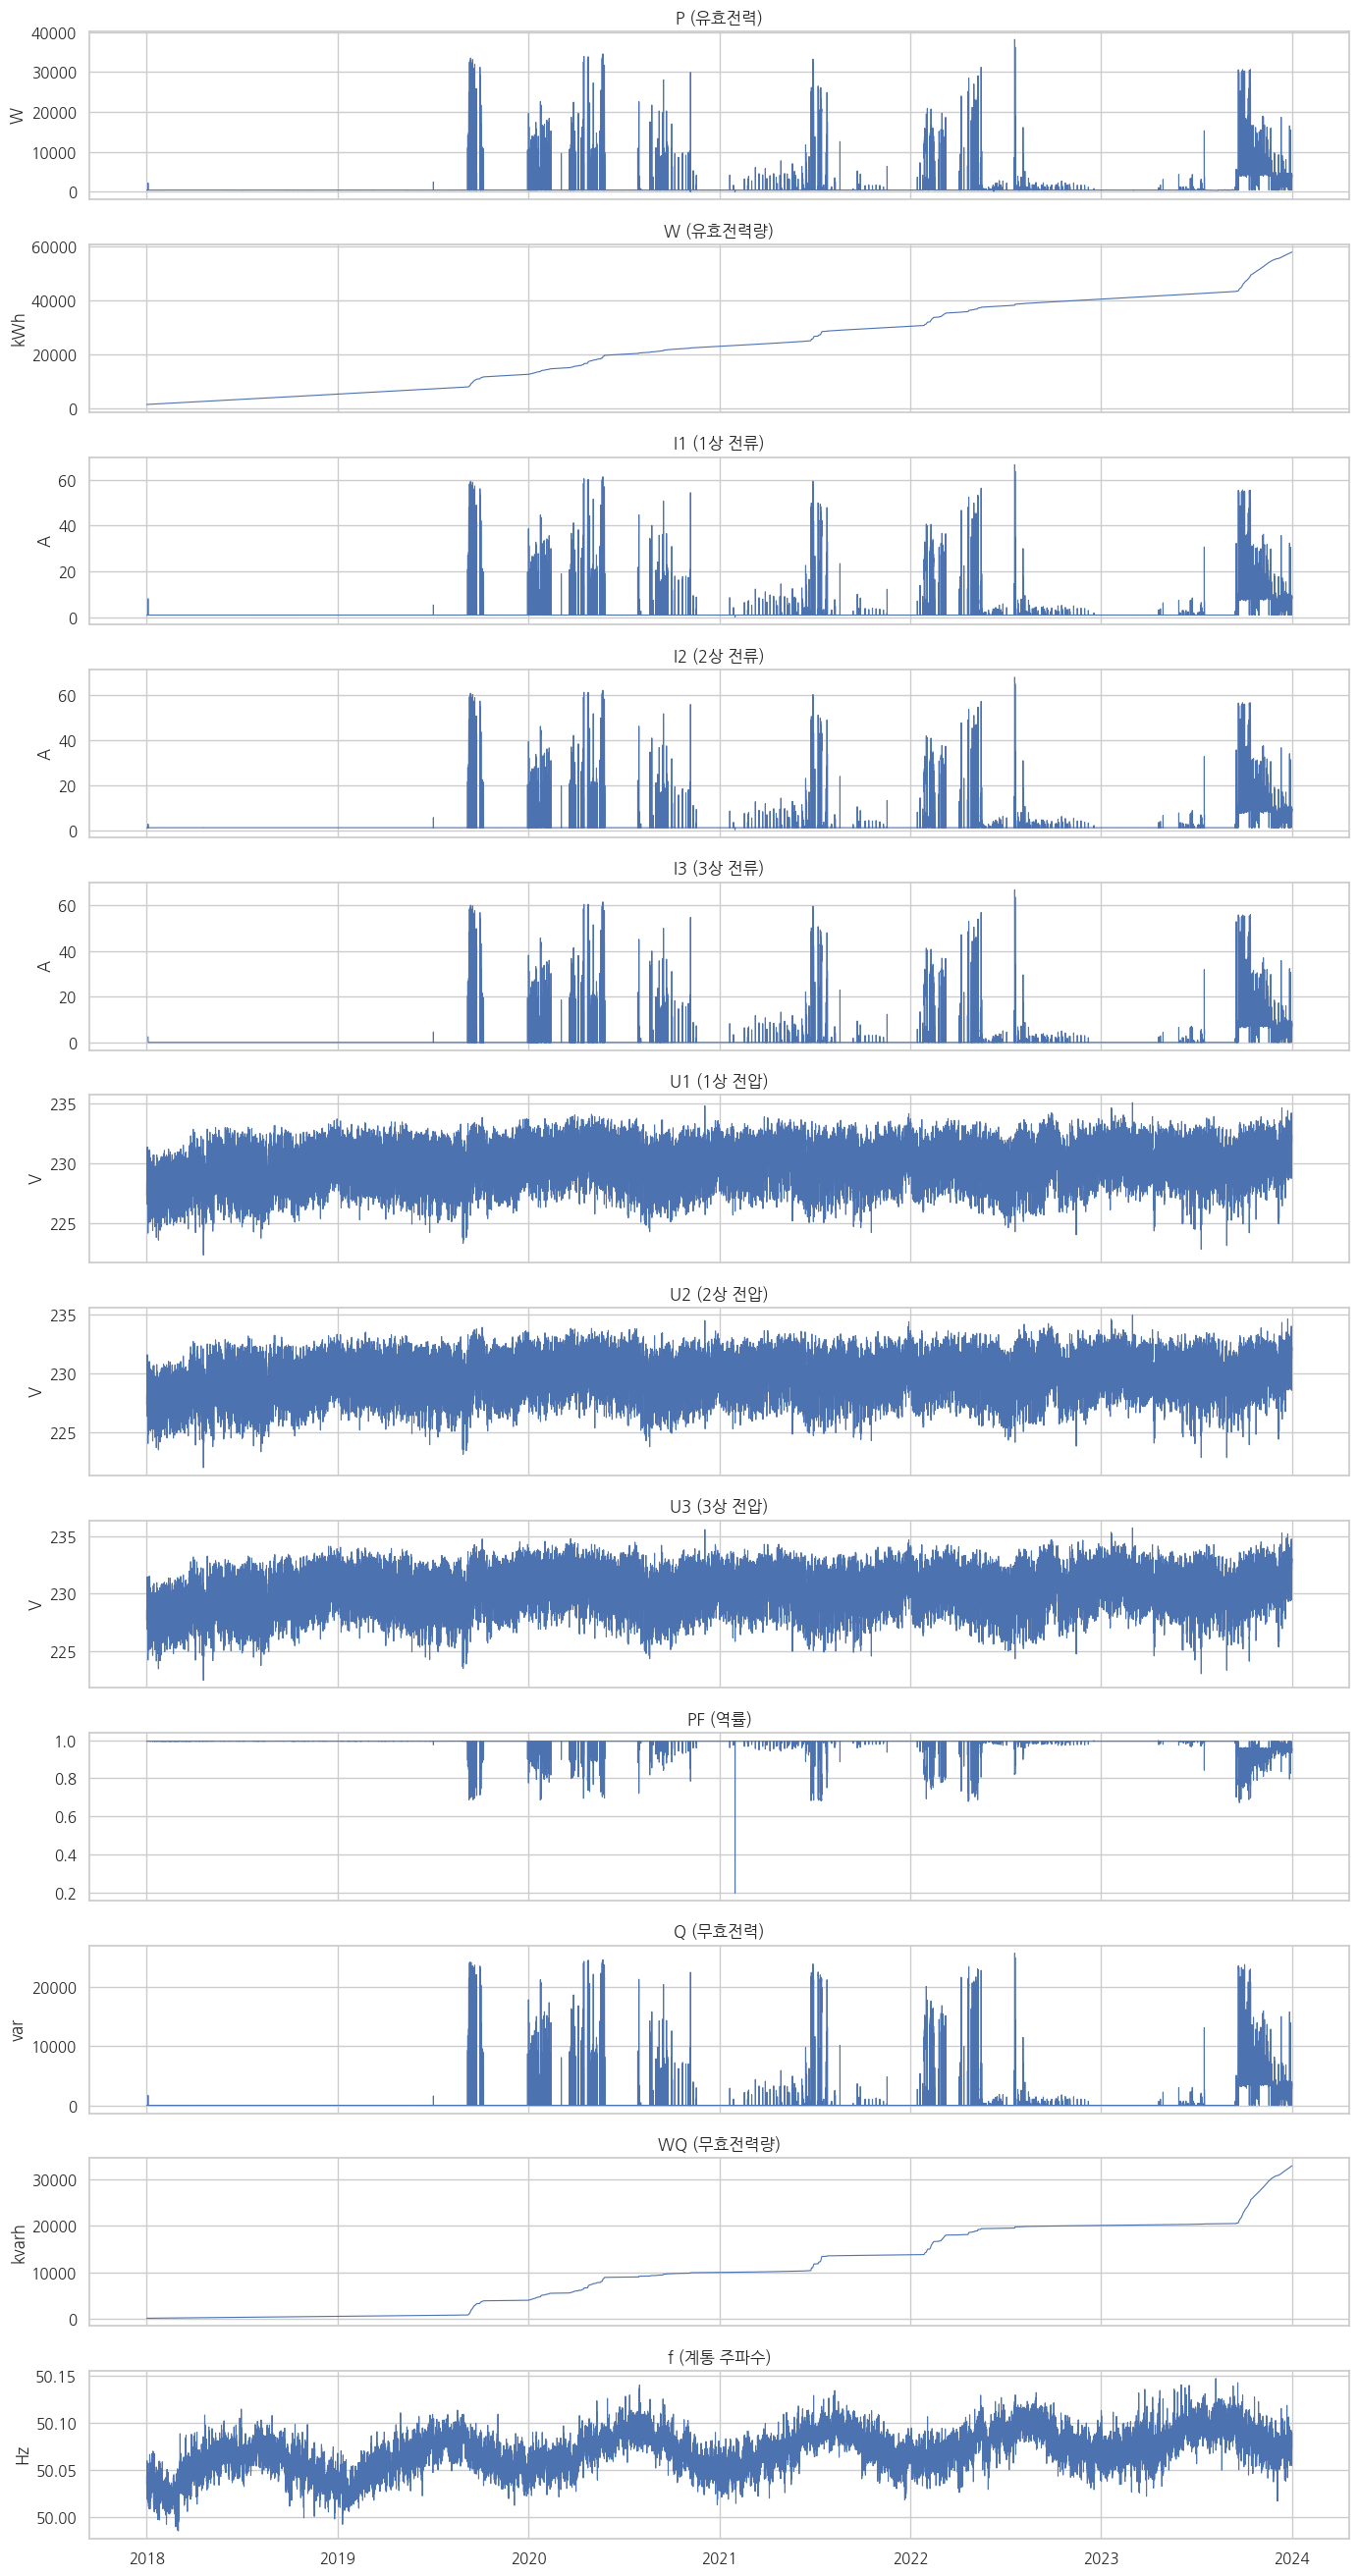

In [14]:
# 14. 주요 변수 시계열 preview
measurement_labels = {
    'P': 'P (유효전력)',
    'W': 'W (유효전력량)',
    'I1': 'I1 (1상 전류)',
    'I2': 'I2 (2상 전류)',
    'I3': 'I3 (3상 전류)',
    'U1': 'U1 (1상 전압)',
    'U2': 'U2 (2상 전압)',
    'U3': 'U3 (3상 전압)',
    'PF': 'PF (역률)',
    'Q': 'Q (무효전력)',
    'WQ': 'WQ (무효전력량)',
    'f': 'f (계통 주파수)',
}

measurement_units = {
    'P': 'W',
    'W': 'kWh',
    'I1': 'A',
    'I2': 'A',
    'I3': 'A',
    'U1': 'V',
    'U2': 'V',
    'U3': 'V',
    'PF': '',
    'Q': 'var',
    'WQ': 'kvarh',
    'f': 'Hz',
}

plot_cols = [
    c for c in ['P', 'W', 'I1', 'I2', 'I3', 'U1', 'U2', 'U3', 'PF', 'Q', 'WQ', 'f']
    if c in wide.columns
]

fig, axes = plt.subplots(
    len(plot_cols),
    1,
    figsize=(14, max(3, 2.2 * len(plot_cols))),
    sharex=True,
)

if len(plot_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, plot_cols):
    ax.plot(wide.index, wide[col], linewidth=0.8)
    ax.set_title(measurement_labels.get(col, col))

    unit = measurement_units.get(col, '')
    if unit:
        ax.set_ylabel(unit)

plt.tight_layout()
plt.show()

,stat,P [W]
0,count,52584.000000
1,mean,1073.455926
2,median,440.270042
3,q90,451.164297
4,q95,4400.753575
5,q99,15956.566304
6,max,38167.579833


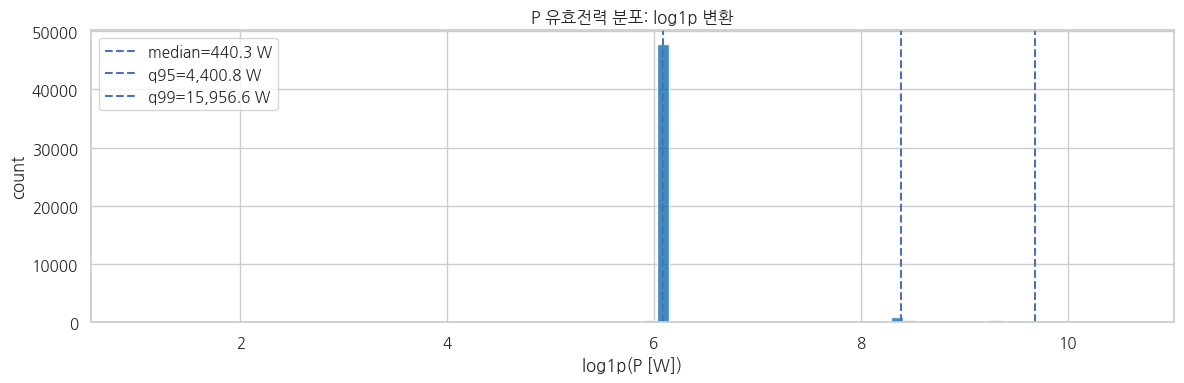

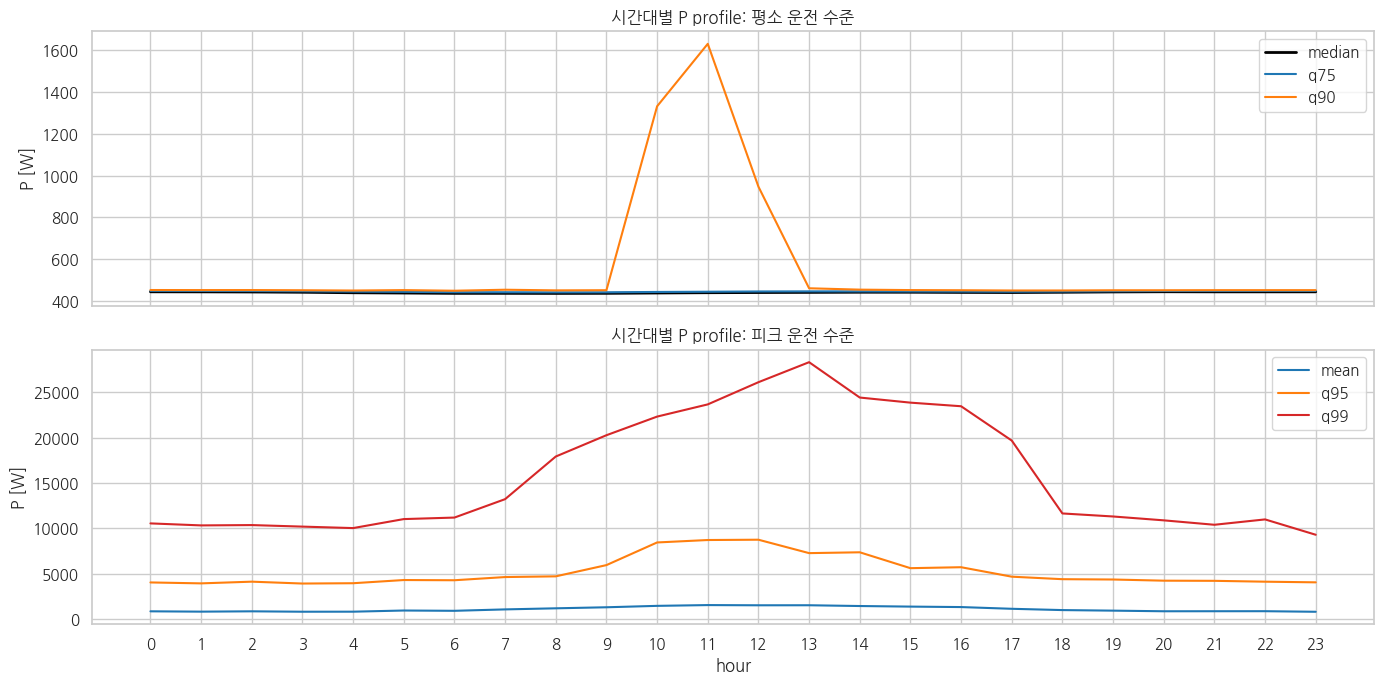

In [15]:
# 15. P 유효전력 profile
if 'P' in wide.columns:
    p = wide['P'].dropna()

    q = p.quantile([0.50, 0.90, 0.95, 0.99])
    summary = pd.DataFrame({
        'stat': ['count', 'mean', 'median', 'q90', 'q95', 'q99', 'max'],
        'P [W]': [
            p.count(),
            p.mean(),
            q.loc[0.50],
            q.loc[0.90],
            q.loc[0.95],
            q.loc[0.99],
            p.max(),
        ],
    })
    display(summary)

    # 1) 분포: 원본 histogram은 한쪽으로 몰리므로 log1p(P)만 표시
    fig, ax = plt.subplots(figsize=(12, 4))

    ax.hist(np.log1p(p), bins=80, color='tab:blue', alpha=0.85)
    ax.set_title('P 유효전력 분포: log1p 변환')
    ax.set_xlabel('log1p(P [W])')
    ax.set_ylabel('count')

    for value, label in [
        (q.loc[0.50], 'median'),
        (q.loc[0.95], 'q95'),
        (q.loc[0.99], 'q99'),
    ]:
        ax.axvline(
            np.log1p(value),
            linestyle='--',
            linewidth=1.5,
            label=f'{label}={value:,.1f} W',
        )

    ax.legend()
    plt.tight_layout()
    plt.show()

    # 2) 시간대별 profile: 평소 운전 수준과 피크 수준을 분리해서 표시
    profile = wide.assign(hour=wide.index.hour)

    hourly = profile.groupby('hour')['P'].agg(
        median='median',
        q75=lambda x: x.quantile(0.75),
        q90=lambda x: x.quantile(0.90),
        q95=lambda x: x.quantile(0.95),
        q99=lambda x: x.quantile(0.99),
        mean='mean',
    )

    fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

    # 평소 운전 수준: median, q75, q90
    axes[0].plot(hourly.index, hourly['median'], label='median', color='black', linewidth=2)
    axes[0].plot(hourly.index, hourly['q75'], label='q75', color='tab:blue', linewidth=1.5)
    axes[0].plot(hourly.index, hourly['q90'], label='q90', color='tab:orange', linewidth=1.5)
    axes[0].set_title('시간대별 P profile: 평소 운전 수준')
    axes[0].set_ylabel('P [W]')
    axes[0].legend()

    # 피크 운전 수준: mean, q95, q99
    axes[1].plot(hourly.index, hourly['mean'], label='mean', color='tab:blue', linewidth=1.5)
    axes[1].plot(hourly.index, hourly['q95'], label='q95', color='tab:orange', linewidth=1.5)
    axes[1].plot(hourly.index, hourly['q99'], label='q99', color='tab:red', linewidth=1.5)
    axes[1].set_title('시간대별 P profile: 피크 운전 수준')
    axes[1].set_xlabel('hour')
    axes[1].set_ylabel('P [W]')
    axes[1].set_xticks(range(24))
    axes[1].legend()

    plt.tight_layout()
    plt.show()

else:
    print('P column not available')

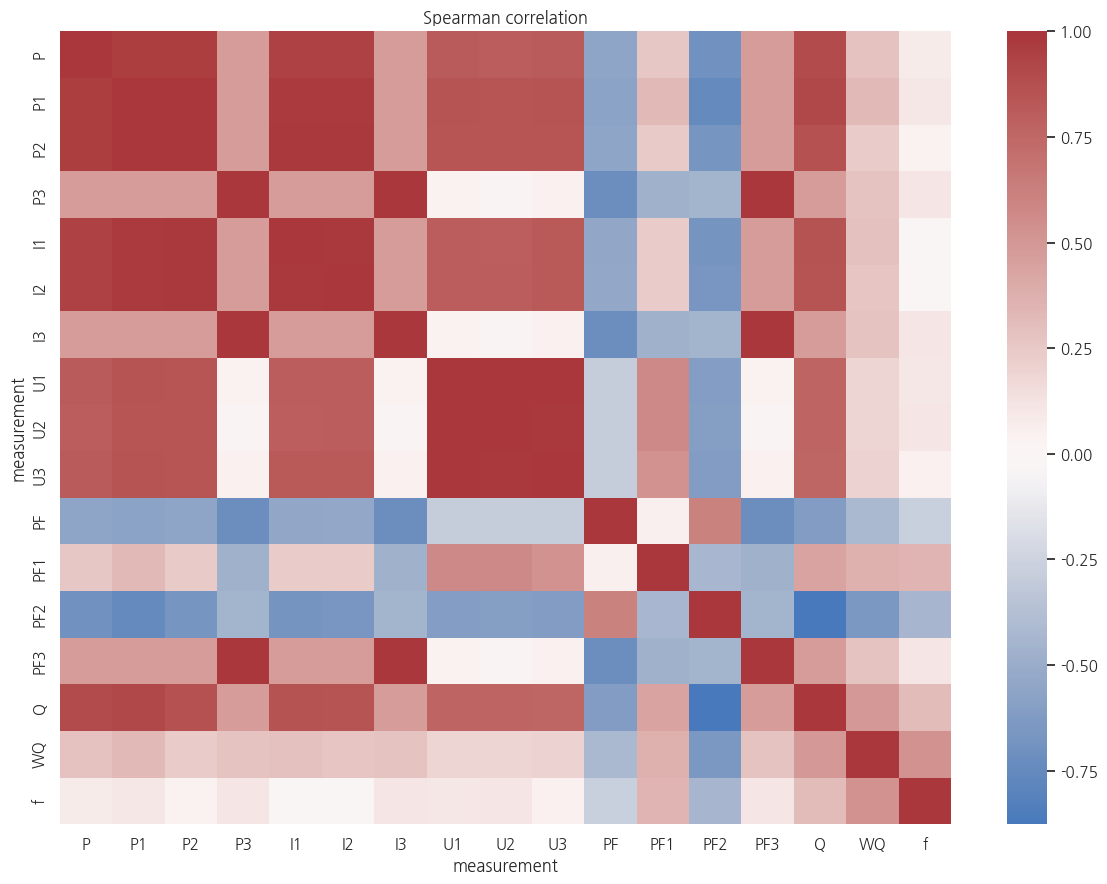

measurement,P,P1,P2,P3,I1,I2,I3,U1,U2,U3,PF,PF1,PF2,PF3,Q,WQ,f
measurement,,,,,,,,,,,,,,,,,
P,1.000000,0.960922,0.959216,0.472278,0.944107,0.945651,0.472278,0.810682,0.804719,0.810033,-0.560408,0.264322,-0.697398,0.472320,0.892875,0.284724,0.078947
P1,0.960922,1.000000,0.990759,0.472283,0.977156,0.976129,0.472281,0.853146,0.845633,0.851135,-0.575884,0.320550,-0.750937,0.472326,0.914651,0.320903,0.103079
P2,0.959216,0.990759,1.000000,0.472273,0.979650,0.982576,0.472281,0.841984,0.841206,0.843032,-0.554724,0.250176,-0.675452,0.472316,0.873911,0.242596,0.041657
P3,0.472278,0.472283,0.472273,1.000000,0.472401,0.472405,0.999888,0.040942,0.031754,0.048692,-0.718710,-0.471221,-0.454273,0.999879,0.472320,0.274718,0.119623
I1,0.944107,0.977156,0.979650,0.472401,1.000000,0.982196,0.472391,0.806929,0.801728,0.816892,-0.540435,0.244310,-0.684464,0.472451,0.859321,0.290930,-0.000785
I2,0.945651,0.976129,0.982576,0.472405,0.982196,1.000000,0.472381,0.808484,0.803291,0.817287,-0.539008,0.231623,-0.669010,0.472454,0.852495,0.267611,-0.007423
I3,0.472278,0.472281,0.472281,0.999888,0.472391,0.472381,1.000000,0.041114,0.031932,0.048870,-0.718639,-0.471206,-0.454219,0.999776,0.472274,0.274774,0.119605
U1,0.810682,0.853146,0.841984,0.040942,0.806929,0.808484,0.041114,1.000000,0.993311,0.985615,-0.295068,0.570907,-0.612262,0.040811,0.769651,0.190584,0.098430
U2,0.804719,0.845633,0.841206,0.031754,0.801728,0.803291,0.031932,0.993311,1.000000,0.982976,-0.290479,0.569011,-0.604217,0.031629,0.769386,0.189656,0.107903


In [16]:
# 16. 상관 구조 확인
corr_cols = [c for c in ['P', 'P1', 'P2', 'P3', 'I1', 'I2', 'I3', 'U1', 'U2', 'U3', 'PF', 'PF1', 'PF2', 'PF3', 'Q', 'WQ', 'f'] if c in wide.columns]
if len(corr_cols) >= 2:
    corr = wide[corr_cols].corr(method='spearman')
    plt.figure(figsize=(12, 9))
    sns.heatmap(corr, cmap='vlag', center=0, annot=False)
    plt.title('Spearman correlation')
    plt.tight_layout()
    plt.show()
    display(corr)
else:
    print('Correlation requires at least two columns')